In [4]:
from sklearn.feature_extraction.text import CountVectorizer
v = CountVectorizer(ngram_range=(1, 3))
v.fit(["Harry potter of the order of the phoenix"])
print(v.vocabulary_)
print(v.transform(["Harry prtter of the order of the phoenix"]))

{'harry': 0, 'potter': 11, 'of': 3, 'the': 14, 'order': 7, 'phoenix': 10, 'harry potter': 1, 'potter of': 12, 'of the': 4, 'the order': 15, 'order of': 8, 'the phoenix': 17, 'harry potter of': 2, 'potter of the': 13, 'of the order': 5, 'the order of': 16, 'order of the': 9, 'of the phoenix': 6}
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 13 stored elements and shape (1, 18)>
  Coords	Values
  (0, 0)	1
  (0, 3)	2
  (0, 4)	2
  (0, 5)	1
  (0, 6)	1
  (0, 7)	1
  (0, 8)	1
  (0, 9)	1
  (0, 10)	1
  (0, 14)	2
  (0, 15)	1
  (0, 16)	1
  (0, 17)	1


In [8]:
corpus = [
    "Harry potter of the order of the phoenix",
    "Harry potter and the chamber of secrets",
    "Harry potter and the prisoner of azkaban",
]

In [6]:
import spacy
nlp = spacy.load("en_core_web_sm")
def processess(text):
  doc = nlp(text)
  filtered_token = []
  for token in doc:
    if token.is_stop or token.is_punct:
      continue
    filtered_token.append(token.lemma_)
  return " ".join(filtered_token)

processess("Harry potter of the order of the phoenix")

'Harry potter order phoenix'

In [9]:
corpus_process = [processess(text) for text in corpus]
print(corpus_process)

['Harry potter order phoenix', 'Harry potter chamber secret', 'Harry potter prisoner azkaban']


In [10]:
v = CountVectorizer(ngram_range=(1, 2))
v.fit(corpus_process)
print(v.vocabulary_)

{'harry': 3, 'potter': 8, 'order': 5, 'phoenix': 7, 'harry potter': 4, 'potter order': 10, 'order phoenix': 6, 'chamber': 1, 'secret': 14, 'potter chamber': 9, 'chamber secret': 2, 'prisoner': 12, 'azkaban': 0, 'potter prisoner': 11, 'prisoner azkaban': 13}


In [11]:
import pandas as pd

news_data = [
    {'index': 1, 'news': 'Global tech giant announces record quarterly profits driven by AI innovation.', 'news category': 'Technology'},
    {'index': 2, 'news': 'Local government passes new environmental protection laws, aiming for zero emissions.', 'news category': 'Environment'},
    {'index': 3, 'news': 'Stock market experiences volatile week amidst inflation concerns and interest rate hikes.', 'news category': 'Finance'},
    {'index': 4, 'news': 'New study reveals potential breakthrough in cancer treatment, offering hope to patients.', 'news category': 'Health'},
    {'index': 5, 'news': 'International summit concludes with agreements on climate change and economic cooperation.', 'news category': 'Politics'},
    {'index': 6, 'news': 'E-commerce boom continues, reshaping retail industry with increased online sales.', 'news category': 'Business'},
    {'index': 7, 'news': 'Scientific expedition discovers new species in Amazon rainforest, highlighting biodiversity.', 'news category': 'Science'},
    {'index': 8, 'news': 'Film festival kicks off with star-studded premiere, showcasing independent cinema.', 'news category': 'Entertainment'},
    {'index': 9, 'news': 'Sports team clinches championship title in thrilling overtime victory, fans celebrate.', 'news category': 'Sports'},
    {'index': 10, 'news': 'Urban development project promises affordable housing and revitalized community spaces.', 'news category': 'Urban Planning'},
    {'index': 11, 'news': 'Artificial intelligence advancements lead to ethical debates on data privacy and job displacement.', 'news category': 'Technology'},
    {'index': 12, 'news': 'Forest fires rage across several regions, prompting evacuation orders and emergency response.', 'news category': 'Environment'},
    {'index': 13, 'news': 'Central bank intervenes to stabilize currency, preventing further economic downturn.', 'news category': 'Finance'},
    {'index': 14, 'news': 'Vaccine development progresses against new viral strain, trials show promising results.', 'news category': 'Health'},
    {'index': 15, 'news': 'Election campaign heats up with major candidates debating key policy issues.', 'news category': 'Politics'},
    {'index': 16, 'news': 'Merger and acquisition activity increases in the pharmaceutical sector, driven by innovation.', 'news category': 'Business'},
    {'index': 17, 'news': 'Space agency successfully launches new telescope, aiming to explore distant galaxies.', 'news category': 'Science'},
    {'index': 18, 'news': 'Music industry adapts to streaming era, artists find new ways to connect with fans.', 'news category': 'Entertainment'},
    {'index': 19, 'news': 'Olympic preparations underway, athletes train rigorously for upcoming international games.', 'news category': 'Sports'},
    {'index': 20, 'news': 'Public transportation expansion project aims to reduce traffic congestion in metropolitan areas.', 'news category': 'Urban Planning'},
    {'index': 21, 'news': 'New smartphone model unveiled with advanced camera features and longer battery life.', 'news category': 'Technology'},
    {'index': 22, 'news': 'Renewable energy investments surge as countries commit to carbon neutrality goals.', 'news category': 'Environment'},
    {'index': 23, 'news': 'Global economists warn of impending recession if current economic trends continue.', 'news category': 'Finance'},
    {'index': 24, 'news': 'Mental health awareness campaign launched to destigmatize therapy and provide support.', 'news category': 'Health'},
    {'index': 25, 'news': 'Diplomatic talks begin to resolve international trade disputes and foster cooperation.', 'news category': 'Politics'}
]

df_news = pd.DataFrame(news_data)

display(df_news.head())


,index,news,news category
0,1,Global tech giant announces record quarterly p...,Technology
1,2,Local government passes new environmental prot...,Environment
2,3,Stock market experiences volatile week amidst ...,Finance
3,4,New study reveals potential breakthrough in ca...,Health
4,5,International summit concludes with agreements...,Politics


In [12]:
df_news.to_csv('news_dataset.csv', index=False)
print('news_dataset.csv has been saved to the files section.')

news_dataset.csv has been saved to the files section.


In [14]:
df_news['news category'].value_counts()

,count
news category,
Technology,3
Environment,3
Finance,3
Health,3
Politics,3
Business,2
Science,2
Entertainment,2
Sports,2


In [20]:
min_samples_per_class = 3
df_Technology = df_news[df_news['news category'] == 'Technology'].sample(min_samples_per_class, random_state=42)
df_Environment = df_news[df_news['news category'] == 'Environment'].sample(min_samples_per_class, random_state=42)
df_Finance = df_news[df_news['news category'] == 'Finance'].sample(min_samples_per_class, random_state=42)
df_Health = df_news[df_news['news category'] == 'Health'].sample(min_samples_per_class, random_state=42)

In [21]:
df_balanced = pd.concat([df_Technology, df_Environment, df_Finance, df_Health], axis=0)
df_balanced['news category'].value_counts()

,count
news category,
Technology,3
Environment,3
Finance,3
Health,3


In [22]:
df_balanced['news category num'] = df_balanced['news category'].map({
    'Technology': 0,
    'Environment': 1,
    'Finance': 2,
    'Health': 3
})
df_balanced

,index,news,news category,news category num
0,1,Global tech giant announces record quarterly p...,Technology,0
10,11,Artificial intelligence advancements lead to e...,Technology,0
20,21,New smartphone model unveiled with advanced ca...,Technology,0
1,2,Local government passes new environmental prot...,Environment,1
11,12,"Forest fires rage across several regions, prom...",Environment,1
21,22,Renewable energy investments surge as countrie...,Environment,1
2,3,Stock market experiences volatile week amidst ...,Finance,2
12,13,"Central bank intervenes to stabilize currency,...",Finance,2
22,23,Global economists warn of impending recession ...,Finance,2
3,4,New study reveals potential breakthrough in ca...,Health,3


In [34]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df_balanced['news'], df_balanced['news category num'], test_size=0.4, stratify=df_balanced['news category num'], random_state=10)

In [30]:
print(X_train.shape)
X_train.head()

(7,)


,news
23,Mental health awareness campaign launched to d...
20,New smartphone model unveiled with advanced ca...
2,Stock market experiences volatile week amidst ...
21,Renewable energy investments surge as countrie...
11,"Forest fires rage across several regions, prom..."


In [35]:
y_train.value_counts()

,count
news category num,
2,2
3,2
0,2
1,1


In [36]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

model = Pipeline([
    ('vectorizer', CountVectorizer(ngram_range=(1, 2))),
    ('nb', MultinomialNB())
])
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         2
           2       0.00      0.00      0.00         1
           3       0.33      1.00      0.50         1

    accuracy                           0.20         5
   macro avg       0.08      0.25      0.12         5
weighted avg       0.07      0.20      0.10         5



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [37]:
X_test[:5]

,news
11,"Forest fires rage across several regions, prom..."
1,Local government passes new environmental prot...
0,Global tech giant announces record quarterly p...
12,"Central bank intervenes to stabilize currency,..."
13,Vaccine development progresses against new vir...


In [38]:
y_test[:5]

,news category num
11,1
1,1
0,0
12,2
13,3


In [39]:
y_pred[:5]

array([0, 3, 2, 3, 3])

In [40]:
df_balanced['preprocesstext'] = df_balanced['news'].apply(processess)
df_balanced

,index,news,news category,news category num,preprocesstext
0,1,Global tech giant announces record quarterly p...,Technology,0,global tech giant announce record quarterly pr...
10,11,Artificial intelligence advancements lead to e...,Technology,0,artificial intelligence advancement lead ethic...
20,21,New smartphone model unveiled with advanced ca...,Technology,0,new smartphone model unveil advanced camera fe...
1,2,Local government passes new environmental prot...,Environment,1,local government pass new environmental protec...
11,12,"Forest fires rage across several regions, prom...",Environment,1,forest fire rage region prompt evacuation orde...
21,22,Renewable energy investments surge as countrie...,Environment,1,renewable energy investment surge country comm...
2,3,Stock market experiences volatile week amidst ...,Finance,2,stock market experience volatile week amidst i...
12,13,"Central bank intervenes to stabilize currency,...",Finance,2,central bank intervene stabilize currency prev...
22,23,Global economists warn of impending recession ...,Finance,2,global economist warn impend recession current...
3,4,New study reveals potential breakthrough in ca...,Health,3,new study reveal potential breakthrough cancer...


In [42]:
X_train, X_test, y_train, y_test = train_test_split(df_balanced['preprocesstext'], df_balanced['news category num'], test_size=0.4, stratify=df_balanced['news category num'], random_state=10)

In [43]:
cif = Pipeline([
    ('vectorizer', CountVectorizer(ngram_range=(1, 2))),
    ('nb', MultinomialNB())
])
cif.fit(X_train, y_train)
y_pred = cif.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         2
           2       0.50      1.00      0.67         1
           3       0.50      1.00      0.67         1

    accuracy                           0.40         5
   macro avg       0.25      0.50      0.33         5
weighted avg       0.20      0.40      0.27         5



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


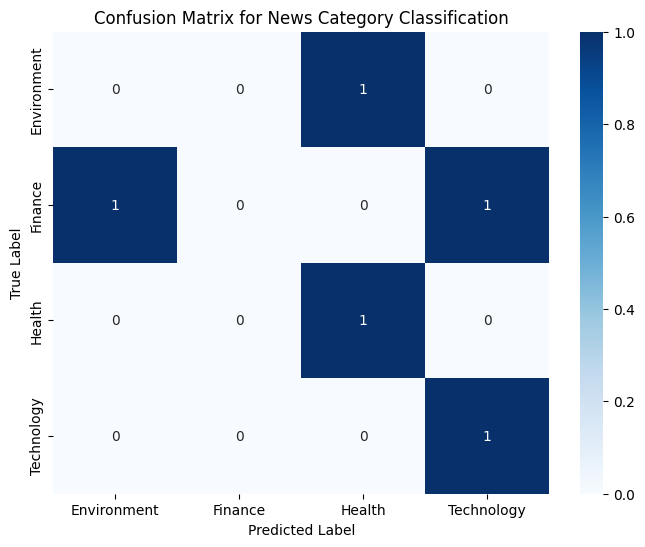

In [44]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Get class labels from the mapped categories in df_balanced
class_labels = df_balanced['news category'].unique()
class_labels.sort() # Ensure consistent order

# Create a figure and an axes for the plot
plt.figure(figsize=(8, 6))

# Display the confusion matrix using seaborn.heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for News Category Classification')
plt.show()